# PVGIS PV factor (generation) temporal profile

PVGIS hourly `P` output for Gothenburg, Sweden, to seasonal hourly `P/Wp` factors

`P` is treated as the PV system output power in watts for the configured PVGIS system size. The UrbanEV-v2 implementation should use `P/Wp` as the dimensionless factor and then multiply by `cfg.getPvWp()` during simulation.

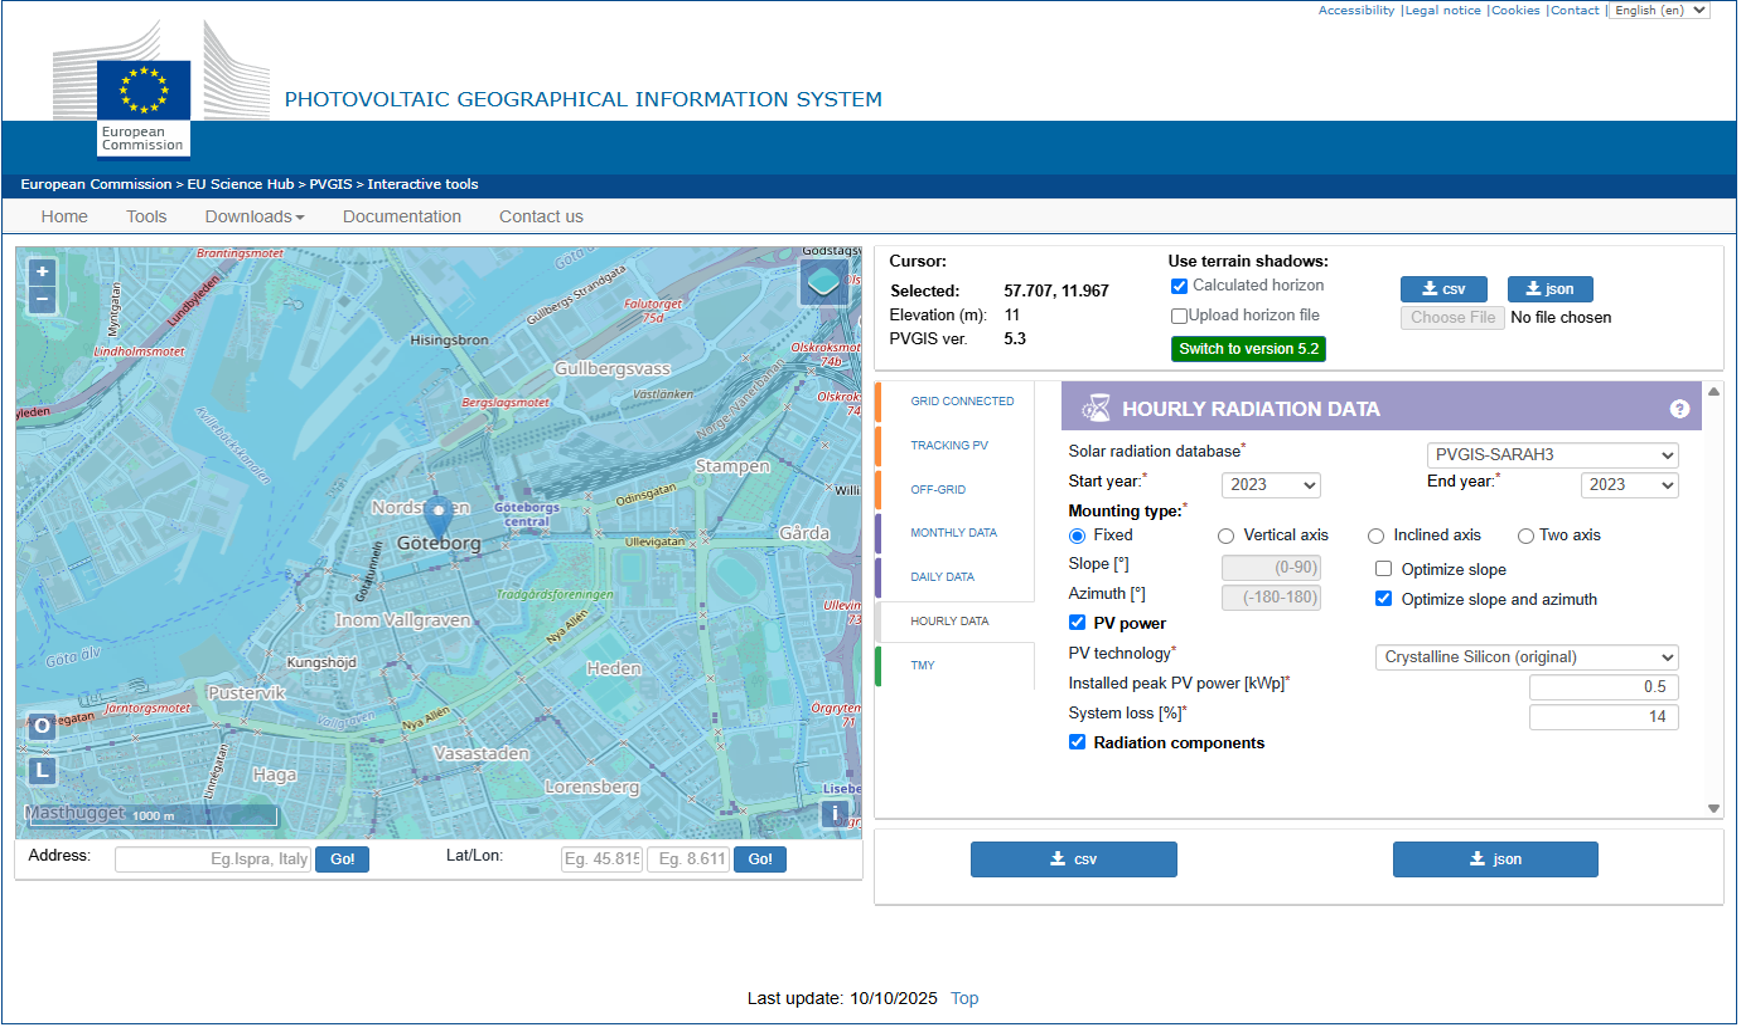

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
FILE_PATH = Path("PVGIS_Timeseries_57.707_11.967_SA3_0kWp_crystSi_14_41deg_5deg_2023.xlsx")
assert FILE_PATH.exists(), f"Workbook not found: {FILE_PATH.resolve()}"
FILE_PATH.resolve()

WindowsPath('C:/Users/omkarp/IdeaProjects/GotVIPV/src/main/java/se/tools/assets/PVGIS_Timeseries_57.707_11.967_SA3_0kWp_crystSi_14_41deg_5deg_2023.xlsx')

In [2]:
def sheet_wp(sheet_name: str) -> float:
    m = re.search(r"(\d+(?:\.\d+)?)\s*Wp", sheet_name)
    if not m:
        raise ValueError(f"Could not infer Wp from sheet name: {sheet_name}")
    return float(m.group(1))

def parse_pvgis_time(series: pd.Series) -> pd.Series:
    # PVGIS time format: YYYYMMDD:HHMM, (20230101:0911)
    return pd.to_datetime(series.astype(str), format="%Y%m%d:%H%M")

xls = pd.ExcelFile(FILE_PATH)
pv_sheets = [s for s in xls.sheet_names if re.search(r"\d+\s*Wp", s)]

records = []
for sheet in pv_sheets:
    wp = sheet_wp(sheet)
    df = pd.read_excel(FILE_PATH, sheet_name=sheet)
    assert "time" in df.columns, f"'time' column missing in {sheet}"
    assert "P" in df.columns, f"'P' column missing in {sheet}"

    df = df.copy()
    df["datetime"] = parse_pvgis_time(df["time"])
    df["month"] = df["datetime"].dt.month
    df["hour"] = df["datetime"].dt.hour
    df["sheet"] = sheet
    df["sheetWp"] = wp
    df["P"] = pd.to_numeric(df["P"], errors="coerce").fillna(0.0)
    df["factor_P_per_Wp"] = df["P"] / df["sheetWp"]
    df["P_1kWp_W"] = df["factor_P_per_Wp"] * 1000.0
    records.append(df[["sheet", "sheetWp", "datetime", "month", "hour", "P", "factor_P_per_Wp", "P_1kWp_W"]])

raw = pd.concat(records, ignore_index=True)

print("Sheets loaded:", pv_sheets)
print("Rows:", len(raw))
print("Columns used:", ["time", "P"])
raw.head()

Sheets loaded: ['400Wp', '700Wp', '1000Wp', '1200Wp']
Rows: 35040
Columns used: ['time', 'P']


,sheet,sheetWp,datetime,month,hour,P,factor_P_per_Wp,P_1kWp_W
0,400Wp,400.0,2023-01-01 00:11:00,1,0,0.0,0.0,0.0
1,400Wp,400.0,2023-01-01 01:11:00,1,1,0.0,0.0,0.0
2,400Wp,400.0,2023-01-01 02:11:00,1,2,0.0,0.0,0.0
3,400Wp,400.0,2023-01-01 03:11:00,1,3,0.0,0.0,0.0
4,400Wp,400.0,2023-01-01 04:11:00,1,4,0.0,0.0,0.0


In [3]:
raw[raw['P_1kWp_W']>894.0].head()

,sheet,sheetWp,datetime,month,hour,P,factor_P_per_Wp,P_1kWp_W
2915,400Wp,400.0,2023-05-02 11:11:00,5,11,357.94,0.894850,894.850000
11675,700Wp,700.0,2023-05-02 11:11:00,5,11,626.39,0.894843,894.842857
20435,1000Wp,1000.0,2023-05-02 11:11:00,5,11,894.84,0.894840,894.840000
29195,1200Wp,1200.0,2023-05-02 11:11:00,5,11,1073.81,0.894842,894.841667


In [4]:
ra = raw[(raw['month'] == 5) & (raw['hour'] == 11)]
print(ra['P_1kWp_W'].mean())

717.9921601382487


## Installed-Wp scaling

Annual energy is calculated by summing hourly power values. Since the time step is one hour, `sum(P)/1000` is annual kWh. If the PVGIS output scales correctly, normalized yield should be almost identical across sheets.


In [5]:
annual = (
    raw.groupby(["sheet", "sheetWp"], as_index=False)
       .agg(annual_kWh=("P", lambda x: x.sum() / 1000.0))
)
annual["annual_kWh_per_kWp"] = annual["annual_kWh"] / (annual["sheetWp"] / 1000.0)
annual

,sheet,sheetWp,annual_kWh,annual_kWh_per_kWp
0,1000Wp,1000.0,951.07784,951.077840
1,1200Wp,1200.0,1141.29315,951.077625
2,400Wp,400.0,380.43090,951.077250
3,700Wp,700.0,665.75356,951.076514


In [6]:
# Pairwise scaling
base_sheet = annual.sort_values("sheetWp").iloc[0]
scale_check = annual.copy()
scale_check["expected_ratio_vs_base"] = scale_check["sheetWp"] / base_sheet["sheetWp"]
scale_check["observed_ratio_vs_base"] = scale_check["annual_kWh"] / base_sheet["annual_kWh"]
scale_check["ratio_error_percent"] = 100.0 * (scale_check["observed_ratio_vs_base"] - scale_check["expected_ratio_vs_base"]) / scale_check["expected_ratio_vs_base"]
scale_check

,sheet,sheetWp,annual_kWh,annual_kWh_per_kWp,expected_ratio_vs_base,observed_ratio_vs_base,ratio_error_percent
0,1000Wp,1000.0,951.07784,951.077840,2.50,2.500002,0.000062
1,1200Wp,1200.0,1141.29315,951.077625,3.00,3.000001,0.000039
2,400Wp,400.0,380.43090,951.077250,1.00,1.000000,0.000000
3,700Wp,700.0,665.75356,951.076514,1.75,1.749999,-0.000077


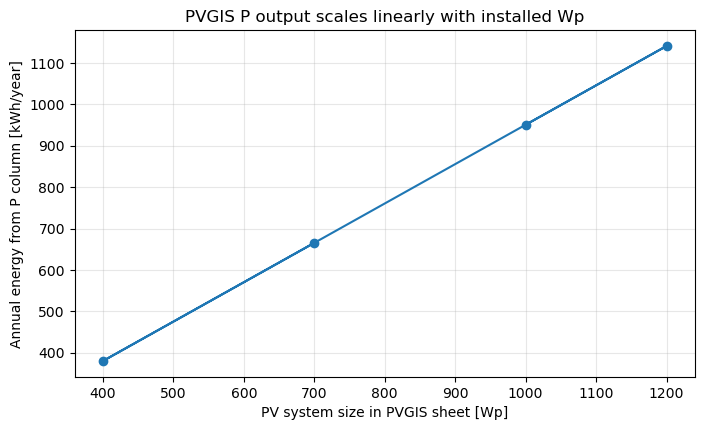

In [7]:
plt.figure(figsize=(8, 4.5))
plt.plot(annual["sheetWp"], annual["annual_kWh"], marker="o")
plt.xlabel("PV system size in PVGIS sheet [Wp]")
plt.ylabel("Annual energy from P column [kWh/year]")
plt.title("PVGIS P output scales linearly with installed Wp")
plt.grid(True, alpha=0.3)
plt.show()

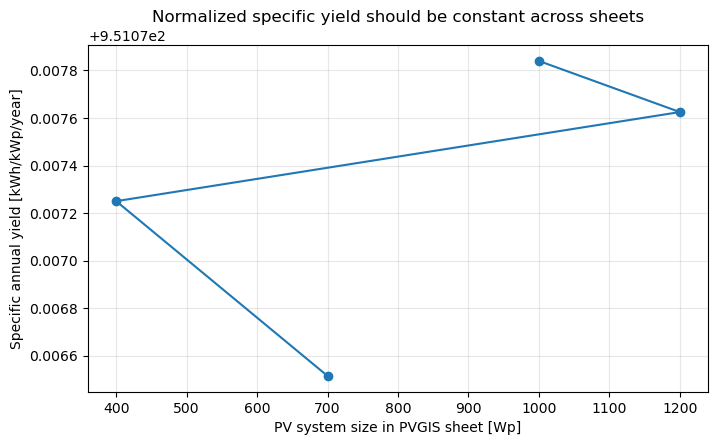

In [8]:
plt.figure(figsize=(8, 4.5))
plt.plot(annual["sheetWp"], annual["annual_kWh_per_kWp"], marker="o")
plt.xlabel("PV system size in PVGIS sheet [Wp]")
plt.ylabel("Specific annual yield [kWh/kWp/year]")
plt.title("Normalized specific yield should be constant across sheets")
plt.grid(True, alpha=0.3)
plt.show()

## Monthly 24-hour mean power profile for a 1 kWp PV system

This plot uses `P/Wp × 1000`, so all sheets collapse into a 1 kWp-equivalent profile. 
The monthly lines explain why the spring seasonal maximum can exceed the summer maximum in this specific PVGIS 2023 extraction.

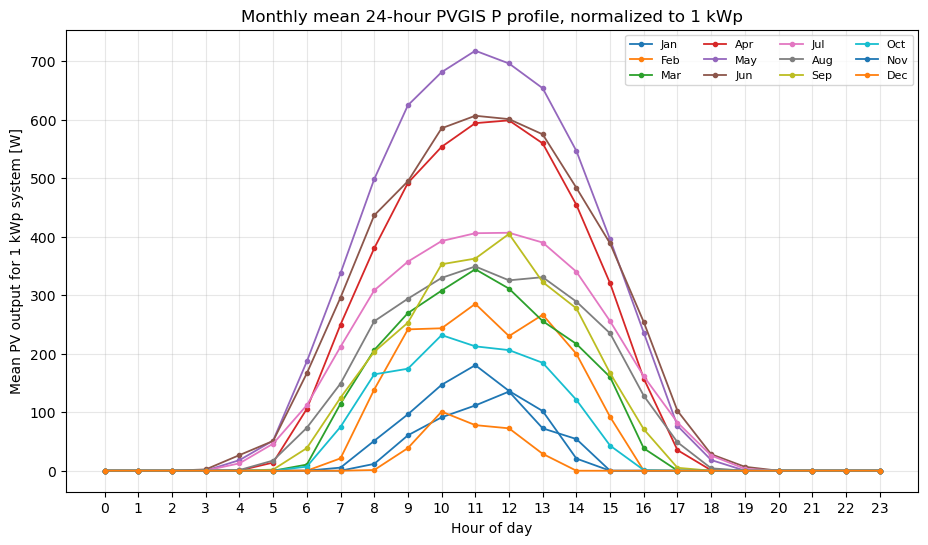

In [9]:
# Average across all Wp sheets after normalization- rounding differences.
monthly_hour = (
    raw.groupby(["month", "hour"], as_index=False)
       .agg(P_1kWp_W=("P_1kWp_W", "mean"),
            factor_P_per_Wp=("factor_P_per_Wp", "mean"))
)

month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

plt.figure(figsize=(11, 6))
for m in range(1, 13):
    sub = monthly_hour[monthly_hour["month"] == m]
    plt.plot(sub["hour"], sub["P_1kWp_W"], marker=".", linewidth=1.3, label=month_names[m])
plt.xlabel("Hour of day")
plt.ylabel("Mean PV output for 1 kWp system [W]")
plt.title("Monthly mean 24-hour PVGIS P profile, normalized to 1 kWp")
plt.xticks(range(0, 24, 1))
plt.grid(True, alpha=0.3)
plt.legend(ncol=4, fontsize=8)
plt.show()

In [10]:
monthly_energy = (
    raw[raw["sheetWp"] == 1000.0]
    .groupby("month", as_index=False)
    .agg(kWh_per_month_1kWp=("P", lambda x: x.sum() / 1000.0))
)
monthly_energy["month_name"] = monthly_energy["month"].map(month_names)
monthly_energy[["month", "month_name", "kWh_per_month_1kWp"]]

,month,month_name,kWh_per_month_1kWp
0,1,Jan,16.64709
1,2,Feb,48.12986
2,3,Mar,69.30500
3,4,Apr,135.50909
4,5,May,177.93482
5,6,Jun,153.17243
6,7,Jul,108.91020
7,8,Aug,87.74821
8,9,Sep,77.55184
9,10,Oct,44.06270


In [11]:
monthly_energy["kWh_per_month_1kWp"].max()

np.float64(177.93482)

## Seasonal aggregation

The seasonal arrays used in `PvPotentialUtils` are calculated as day-weighted hourly means across the relevant months. This is the same quantity needed by `PvGenerationHandler` if it computes:

`powerW = cfg.getPvWp() * PvPotentialUtils.getPotentialFactor(timeSeconds, cfg)`


In [12]:
SEASON_MONTHS = {
    "SPRING": [3, 4, 5],
    "SUMMER": [6, 7, 8],
    "AUTUMN": [9, 10, 11],
    "WINTER": [12, 1, 2],
}

# Day-weighted seasonal hourly factor, computed from all hourly rows
seasonal_hour = (
    raw.assign(season=lambda d: d["month"].map({m: s for s, months in SEASON_MONTHS.items() for m in months}))
       .groupby(["season", "hour"], as_index=False)
       .agg(factor_P_per_Wp=("factor_P_per_Wp", "mean"),
            P_1kWp_W=("P_1kWp_W", "mean"))
)

seasonal_hour.head()

,season,hour,factor_P_per_Wp,P_1kWp_W
0,AUTUMN,0,0.0,0.0
1,AUTUMN,1,0.0,0.0
2,AUTUMN,2,0.0,0.0
3,AUTUMN,3,0.0,0.0
4,AUTUMN,4,0.0,0.0


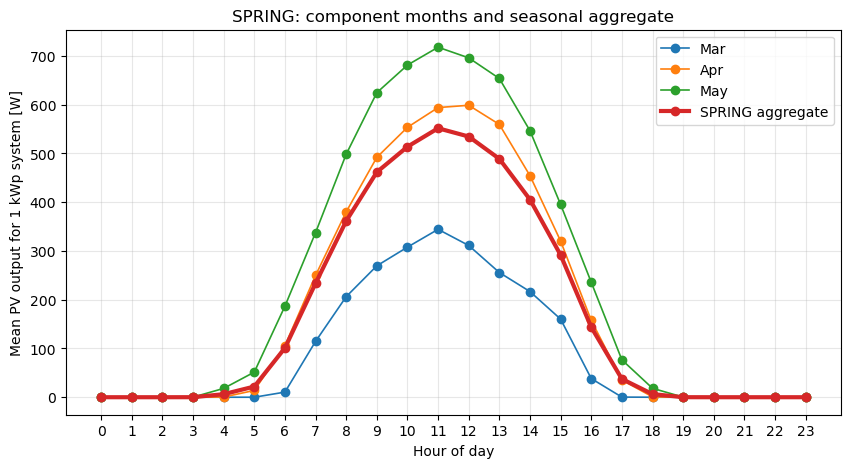

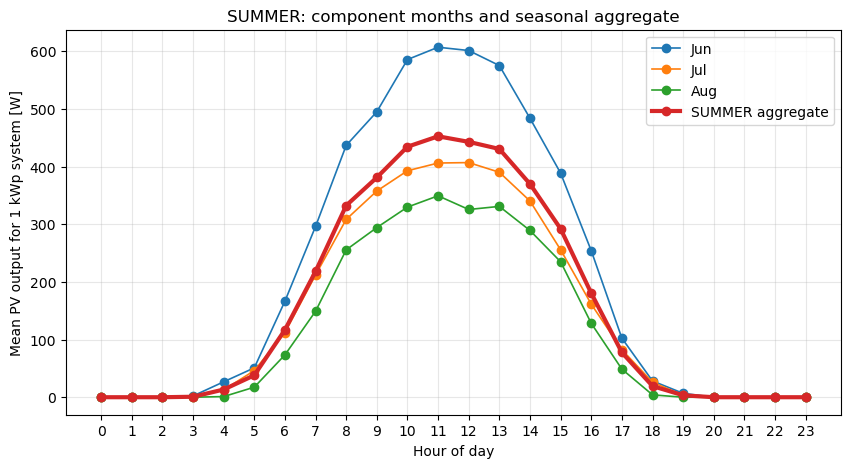

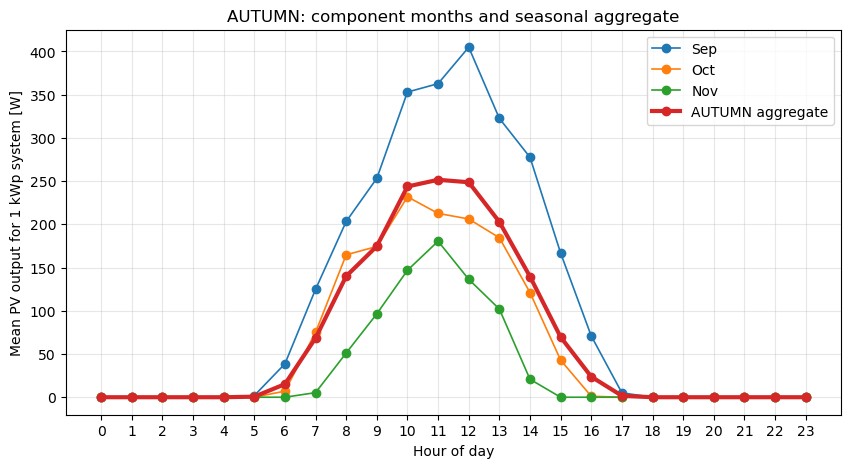

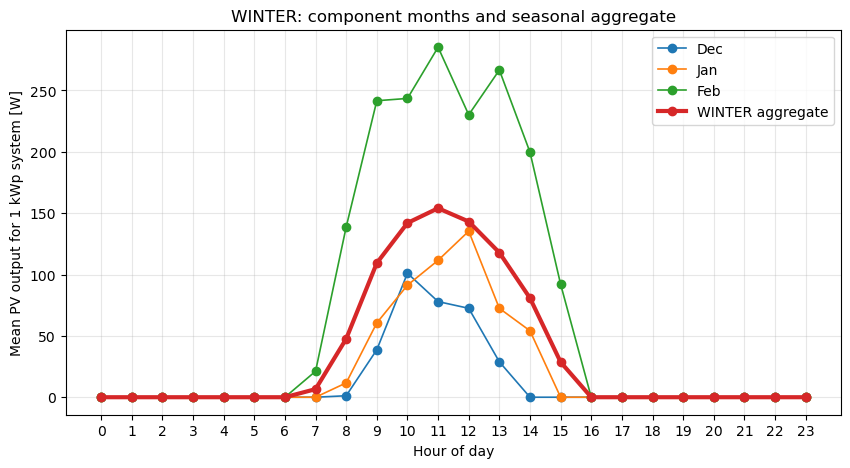

In [13]:
for season, months in SEASON_MONTHS.items():
    plt.figure(figsize=(10, 5))

    for m in months:
        sub_m = monthly_hour[monthly_hour["month"] == m]
        plt.plot(sub_m["hour"], sub_m["P_1kWp_W"], marker="o", linewidth=1.2, label=month_names[m])

    sub_s = seasonal_hour[seasonal_hour["season"] == season]
    plt.plot(sub_s["hour"], sub_s["P_1kWp_W"], marker="o", linewidth=3.0, label=f"{season} aggregate")

    plt.xlabel("Hour of day")
    plt.ylabel("Mean PV output for 1 kWp system [W]")
    plt.title(f"{season}: component months and seasonal aggregate")
    plt.xticks(range(0, 24, 1))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

In [14]:
# sum of 24 hourly mean P/Wp factors- equivalent kWh/kWp/day
seasonal_daily_equivalent = (
    seasonal_hour.groupby("season", as_index=False)
    .agg(daily_kWh_per_kWp=("factor_P_per_Wp", "sum"))
)
seasonal_daily_equivalent.sort_values("daily_kWh_per_kWp", ascending=False)

,season,daily_kWh_per_kWp
1,SPRING,4.160313
2,SUMMER,3.802507
0,AUTUMN,1.580161
3,WINTER,0.830036


In [15]:
def java_array(name: str, values, decimals: int = 6) -> str:
    formatted = [f"{v:.{decimals}f}" for v in values]
    lines = []
    for i in range(0, len(formatted), 6):
        lines.append("        " + ", ".join(formatted[i:i+6]))
    body = ",\n".join(lines)
    return f"private static final double[] {name} = {{\n{body}\n}};"

season_arrays = {}
for season in ["SPRING", "SUMMER", "AUTUMN", "WINTER"]:
    arr = (
        seasonal_hour[seasonal_hour["season"] == season]
        .sort_values("hour")["factor_P_per_Wp"]
        .to_numpy()
    )
    season_arrays[season] = arr
    print(java_array(f"PV_{season}", arr))
    print()

private static final double[] PV_SPRING = {
        0.000000, 0.000000, 0.000000, 0.000069, 0.006223, 0.021895,
        0.100943, 0.233823, 0.361494, 0.461787, 0.513890, 0.551742,
        0.534771, 0.488988, 0.405419, 0.291691, 0.143697, 0.037408,
        0.006413, 0.000059, 0.000000, 0.000000, 0.000000, 0.000000
};

private static final double[] PV_SUMMER = {
        0.000000, 0.000000, 0.000000, 0.000819, 0.013348, 0.038032,
        0.116793, 0.218149, 0.332354, 0.380945, 0.434282, 0.452355,
        0.442750, 0.430413, 0.369740, 0.291962, 0.180375, 0.077546,
        0.019328, 0.003316, 0.000000, 0.000000, 0.000000, 0.000000
};

private static final double[] PV_AUTUMN = {
        0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000624,
        0.015130, 0.068454, 0.139992, 0.174675, 0.243744, 0.251490,
        0.248657, 0.202789, 0.139589, 0.069603, 0.023747, 0.001666,
        0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000
};

private static final double[] PV_WINTER = {

## VIPV generation profiles for selected installed Wp values

These plots show expected instantaneous PV output for one vehicle-mounted PV system in each season:

`expectedPowerW = pvWp × seasonalFactor[hour]`

The actual stored energy in UrbanEV-v2 will be lower when the vehicle battery is already full, which should appear as `pvEnergyWasted_kWh` in `pv_charging_instances.csv`.


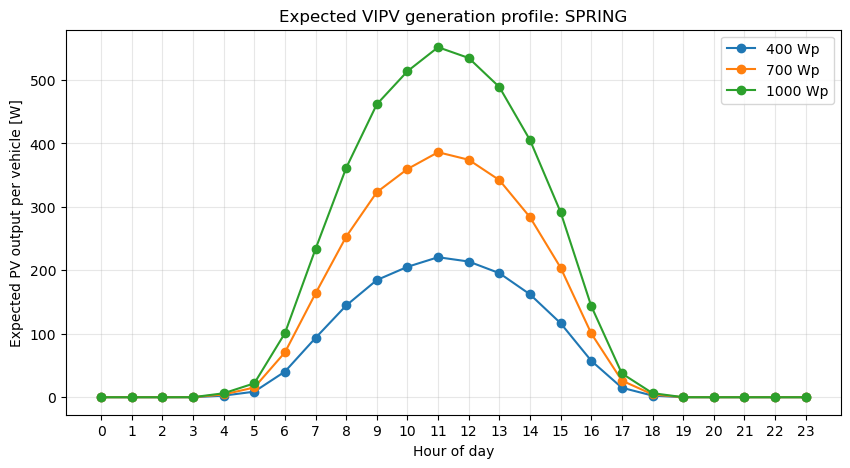

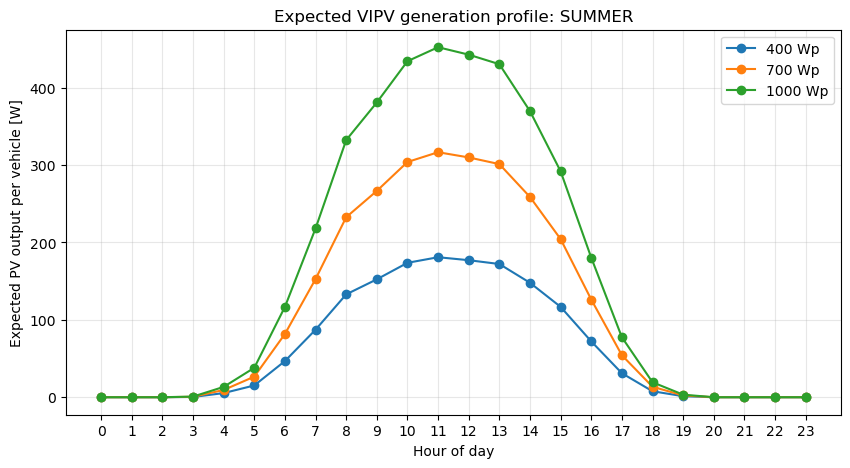

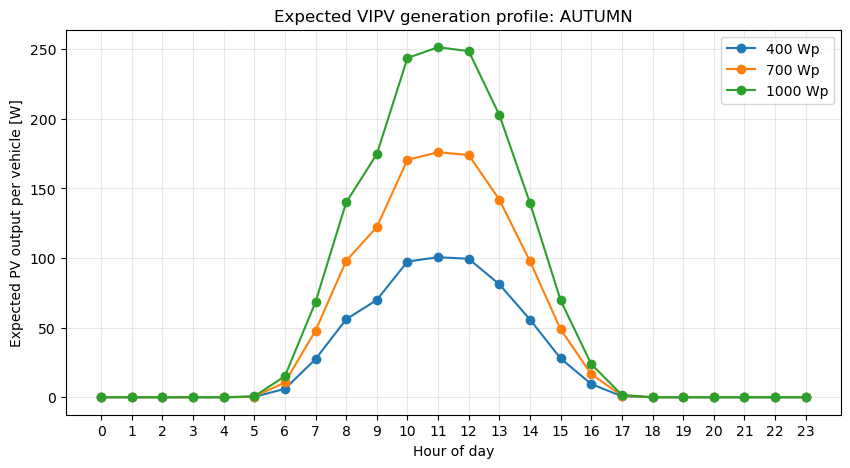

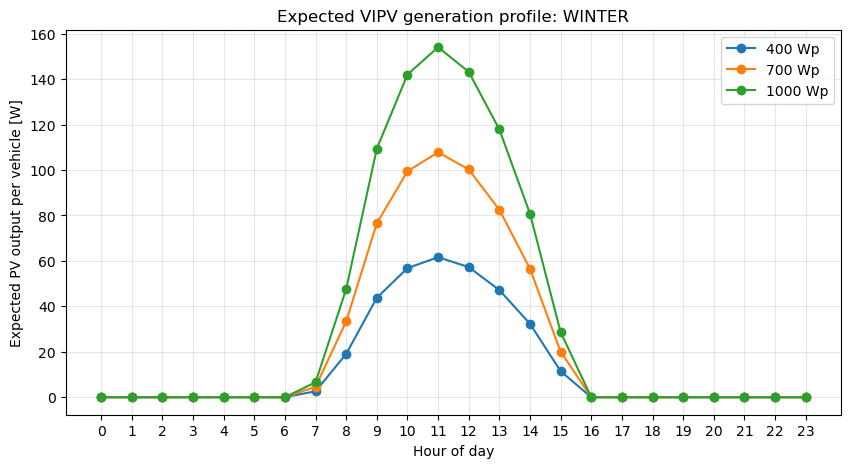

,season,pvWp,daily_kWh_per_vehicle_if_active_all_sun_hours
0,SPRING,400,1.664125
1,SPRING,700,2.912219
2,SPRING,1000,4.160313
3,SUMMER,400,1.521003
4,SUMMER,700,2.661755
5,SUMMER,1000,3.802507
6,AUTUMN,400,0.632064
7,AUTUMN,700,1.106113
8,AUTUMN,1000,1.580161
9,WINTER,400,0.332015


In [16]:
PV_WP_VALUES = [400, 700, 1000]

for season in ["SPRING", "SUMMER", "AUTUMN", "WINTER"]:
    arr = season_arrays[season]
    hours = np.arange(24)

    plt.figure(figsize=(10, 5))
    for wp in PV_WP_VALUES:
        plt.plot(hours, arr * wp, marker="o", label=f"{wp} Wp")

    plt.xlabel("Hour of day")
    plt.ylabel("Expected PV output per vehicle [W]")
    plt.title(f"Expected VIPV generation profile: {season}")
    plt.xticks(range(0, 24, 1))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

daily_energy_rows = []
for season, arr in season_arrays.items():
    for wp in PV_WP_VALUES:
        daily_energy_rows.append({
            "season": season,
            "pvWp": wp,
            "daily_kWh_per_vehicle_if_active_all_sun_hours": arr.sum() * wp / 1000.0
        })

pd.DataFrame(daily_energy_rows)

## monthly arrays

Seasonal arrays are recommended for the current UrbanEV-v2 scenario design. If a later stage needs month-specific simulation..


In [17]:
month_arrays = {}
for m in range(1, 13):
    arr = (
        monthly_hour[monthly_hour["month"] == m]
        .sort_values("hour")["factor_P_per_Wp"]
        .to_numpy()
    )
    month_arrays[m] = arr
    print(java_array(f"PV_MONTH_{m:02d}", arr))
    print()

private static final double[] PV_MONTH_01 = {
        0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
        0.000000, 0.000000, 0.011684, 0.060554, 0.091295, 0.111569,
        0.135313, 0.072445, 0.054143, 0.000000, 0.000000, 0.000000,
        0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000
};

private static final double[] PV_MONTH_02 = {
        0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
        0.000000, 0.021163, 0.138779, 0.241632, 0.243499, 0.285239,
        0.230175, 0.266656, 0.199704, 0.092075, 0.000000, 0.000000,
        0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000
};

private static final double[] PV_MONTH_03 = {
        0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
        0.010482, 0.114507, 0.206272, 0.269543, 0.307878, 0.344421,
        0.311290, 0.255791, 0.216741, 0.160212, 0.038260, 0.000246,
        0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000
};

private static final double[] PV_MONT

Our model does not artificially force summer to have the largest hourly multiplier. The class should use the data-derived `P/Wp` factors, and the scenario parameter `pvWp` should scale the instantaneous generation.

# Monthly PVGIS profiles

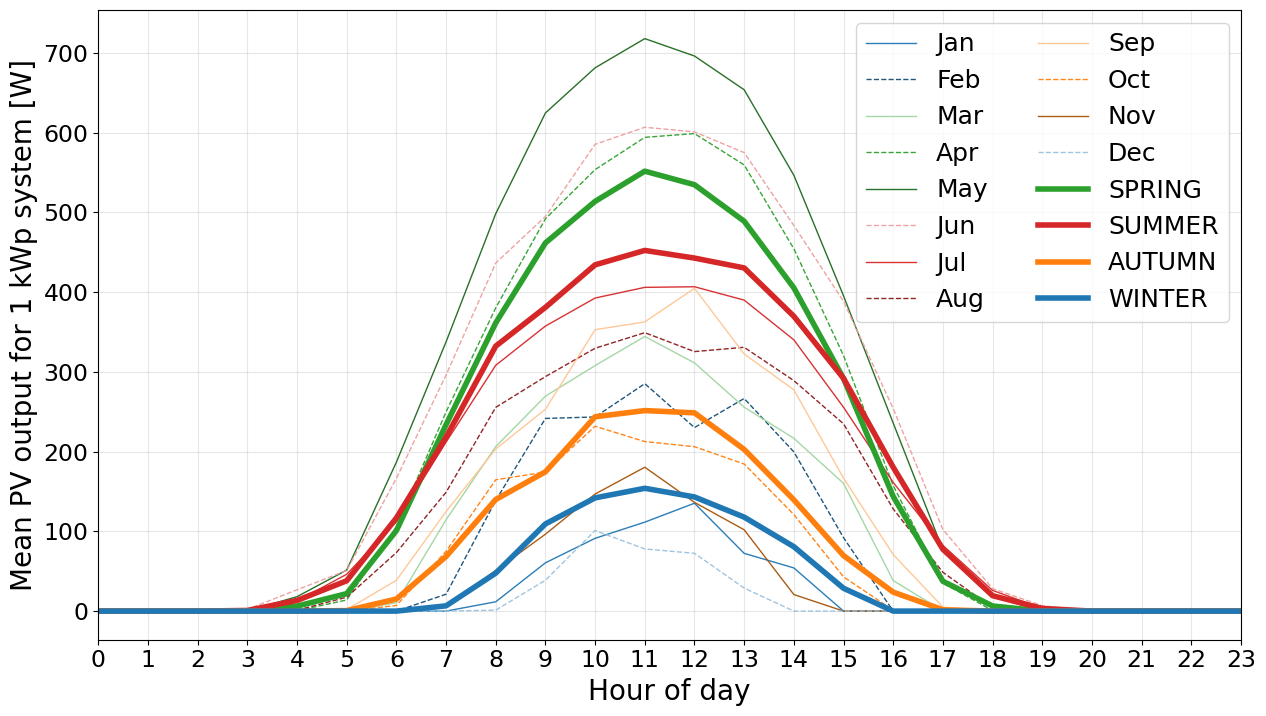

In [18]:
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 21,
    "axes.labelsize": 20,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "legend.fontsize": 18
})

season_colors = {
    "SPRING": "#2ca02c",   # green
    "SUMMER": "#d62728",   # red
    "AUTUMN": "#ff7f0e",   # orange
    "WINTER": "#1f77b4"    # blue
}

def blend_with_white(hex_color, amount):
    rgb = np.array(to_rgb(hex_color))
    white = np.array([1.0, 1.0, 1.0])
    return tuple((1 - amount) * rgb + amount * white)

def blend_with_black(hex_color, amount):
    rgb = np.array(to_rgb(hex_color))
    black = np.array([0.0, 0.0, 0.0])
    return tuple((1 - amount) * rgb + amount * black)

month_to_season = {
    m: season
    for season, months in SEASON_MONTHS.items()
    for m in months
}

month_shades = {}

for season, months in SEASON_MONTHS.items():
    base = season_colors[season]

    if season == "WINTER":
        ordered_months = [12, 1, 2]
    else:
        ordered_months = months

    shades = [
        blend_with_white(base, 0.55),   # light seasonal shade
        to_rgb(base),                   # base seasonal colour
        blend_with_black(base, 0.35)    # dark seasonal shade
    ]

    for m, shade in zip(ordered_months, shades):
        month_shades[m] = shade

line_styles = {
    1: "-",
    2: "--",
    3: "-",
    4: "--",
    5: "-",
    6: "--",
    7: "-",
    8: "--",
    9: "-",
    10: "--",
    11: "-",
    12: "--"
}

fig, ax = plt.subplots(figsize=(13, 7.5))

for m in range(1, 13):
    sub = monthly_hour[monthly_hour["month"] == m].sort_values("hour")

    ax.plot(
        sub["hour"],
        sub["P_1kWp_W"],
        color=month_shades[m],
        linewidth=1.0,
        linestyle=line_styles[m],
        alpha=0.95,
        label=month_names[m]
    )

# Seasonal profiles
for season in ["SPRING", "SUMMER", "AUTUMN", "WINTER"]:
    sub = seasonal_hour[seasonal_hour["season"] == season].sort_values("hour")

    ax.plot(
        sub["hour"],
        sub["P_1kWp_W"],
        color=season_colors[season],
        linewidth=4.0,
        linestyle="-",
        alpha=1.0,
        label=season
    )

ax.set_xlim(0, 23)
ax.set_xticks(range(24))
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean PV output for 1 kWp system [W]")
ax.grid(True, alpha=0.30)

handles, labels = ax.get_legend_handles_labels()

month_handles = handles[:12]
month_labels = labels[:12]

season_handles = handles[12:]
season_labels = labels[12:]

ax.legend(
    month_handles + season_handles,
    month_labels + season_labels,
    ncol=2,
    frameon=True,
    loc="upper right"
)

plt.tight_layout()
plt.savefig("PVprofile.png", dpi=1200)
plt.show()